<a href="https://www.kaggle.com/code/lalit7881/pok-mon-stats-gen-1-6-eda-97?scriptVersionId=327027614" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abbas829/okmon-with-stats-complete-generation-1-6-pokedex/Pokemon.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/abbas829/okmon-with-stats-complete-generation-1-6-pokedex/Pokemon.csv")

In [3]:
df.head()

,number,name,type1,type2,total,hp,attack,defense,sp_attack,sp_defense,speed,generation,legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,Mega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,3,Gigantamax Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False


In [4]:
df.tail()

,number,name,type1,type2,total,hp,attack,defense,sp_attack,sp_defense,speed,generation,legendary
1067,896,Glastrier,Ice,NaN,580,100,145,130,65,110,30,8,True
1068,897,Spectrier,Ghost,NaN,580,100,65,60,145,80,130,8,True
1069,898,Calyrex,Psychic,Grass,500,100,80,80,80,80,80,8,True
1070,898,Ice Rider Calyrex,Psychic,Ice,680,100,165,150,85,130,50,8,True
1071,898,Shadow Rider Calyrex,Psychic,Ghost,680,100,85,80,165,100,150,8,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1072 entries, 0 to 1071
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   number      1072 non-null   int64 
 1   name        1072 non-null   object
 2   type1       1072 non-null   object
 3   type2       574 non-null    object
 4   total       1072 non-null   int64 
 5   hp          1072 non-null   int64 
 6   attack      1072 non-null   int64 
 7   defense     1072 non-null   int64 
 8   sp_attack   1072 non-null   int64 
 9   sp_defense  1072 non-null   int64 
 10  speed       1072 non-null   int64 
 11  generation  1072 non-null   int64 
 12  legendary   1072 non-null   bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 101.7+ KB


In [6]:
df.describe()

,number,total,hp,attack,defense,sp_attack,sp_defense,speed,generation
count,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000
mean,445.219216,440.885261,70.486940,80.938433,74.968284,73.273321,72.476679,68.792910,4.294776
std,267.772806,121.379077,26.868039,32.463582,31.208059,32.643119,27.934253,30.076281,2.346472
min,1.000000,175.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,0.000000
25%,209.750000,330.000000,50.000000,56.000000,52.000000,50.000000,50.000000,45.000000,2.000000
50%,442.500000,460.500000,68.000000,80.000000,70.000000,65.000000,70.000000,65.000000,4.000000
75%,681.250000,519.250000,84.000000,100.000000,90.000000,95.000000,90.000000,90.000000,6.000000
max,898.000000,1125.000000,255.000000,190.000000,250.000000,194.000000,250.000000,200.000000,8.000000


In [7]:
df.isnull().sum()

number          0
name            0
type1           0
type2         498
total           0
hp              0
attack          0
defense         0
sp_attack       0
sp_defense      0
speed           0
generation      0
legendary       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

number         int64
name          object
type1         object
type2         object
total          int64
hp             int64
attack         int64
defense        int64
sp_attack      int64
sp_defense     int64
speed          int64
generation     int64
legendary       bool
dtype: object

In [10]:
df.shape

(1072, 13)

In [11]:
df.columns

Index(['number', 'name', 'type1', 'type2', 'total', 'hp', 'attack', 'defense',
       'sp_attack', 'sp_defense', 'speed', 'generation', 'legendary'],
      dtype='object')

In [12]:
df.nunique()

number         898
name          1072
type1           20
type2           18
total          219
hp             103
attack         123
defense        114
sp_attack      119
sp_defense     107
speed          127
generation       9
legendary        2
dtype: int64

## EDA

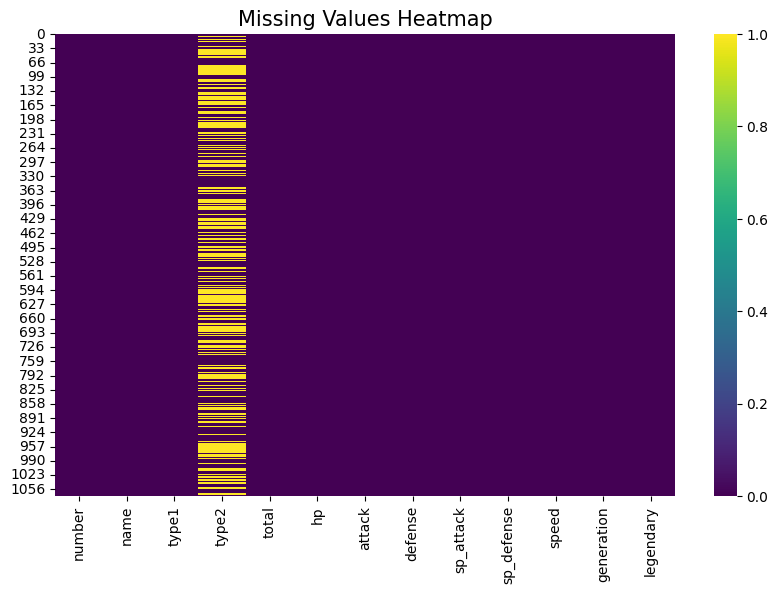

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cmap='viridis', cbar=True)
plt.title('Missing Values Heatmap', fontsize=15)
plt.show()

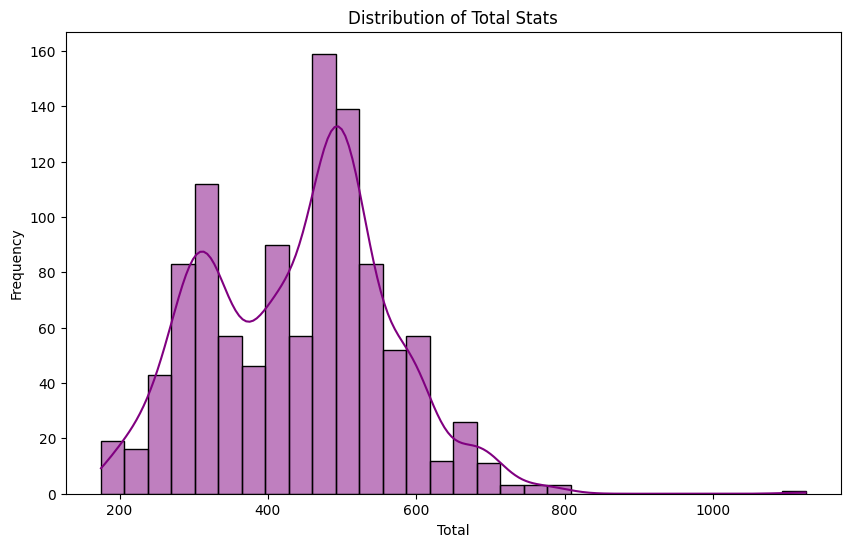

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df['total'], bins=30, kde=True, color='purple')
plt.title('Distribution of Total Stats')
plt.xlabel('Total')
plt.ylabel('Frequency')
plt.show()

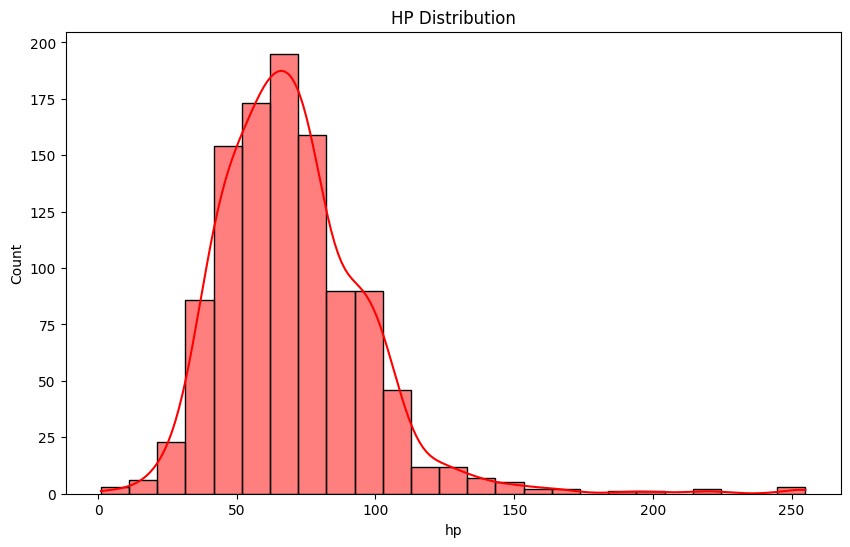

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df['hp'], bins=25, kde=True, color='red')
plt.title('HP Distribution')
plt.show()

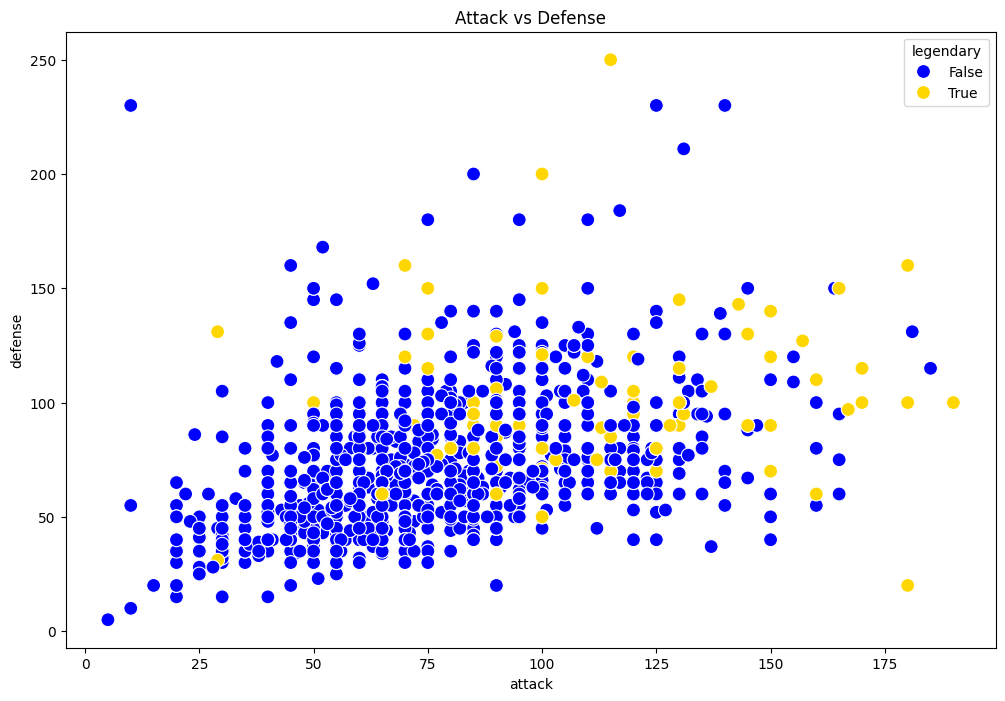

In [16]:
plt.figure(figsize=(12,8))
sns.scatterplot(
    data=df,
    x='attack',
    y='defense',
    hue='legendary',
    palette=['blue','gold'],
    s=100
)

plt.title('Attack vs Defense')
plt.show()

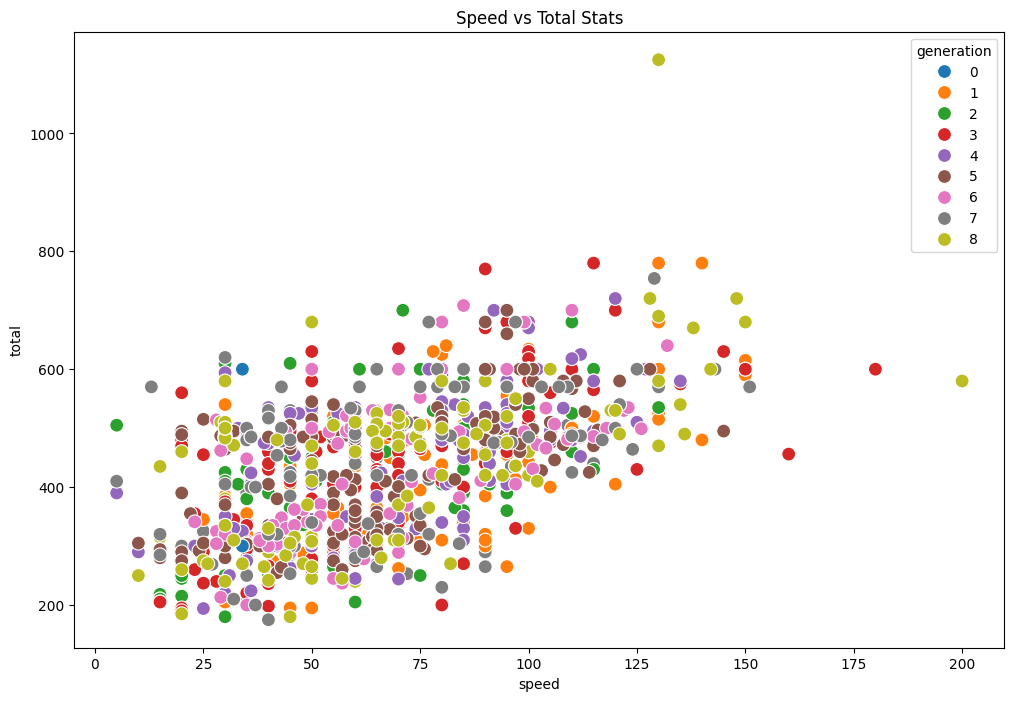

In [17]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x='speed',
    y='total',
    hue='generation',
    palette='tab10',
    s=100
)

plt.title('Speed vs Total Stats')
plt.show()

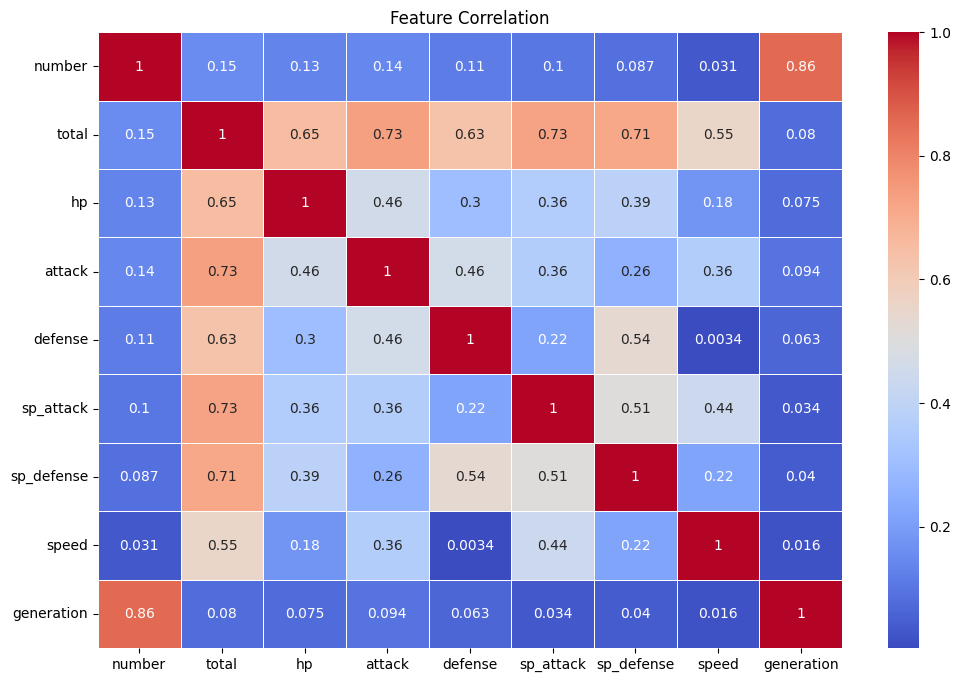

In [18]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Feature Correlation')
plt.show()

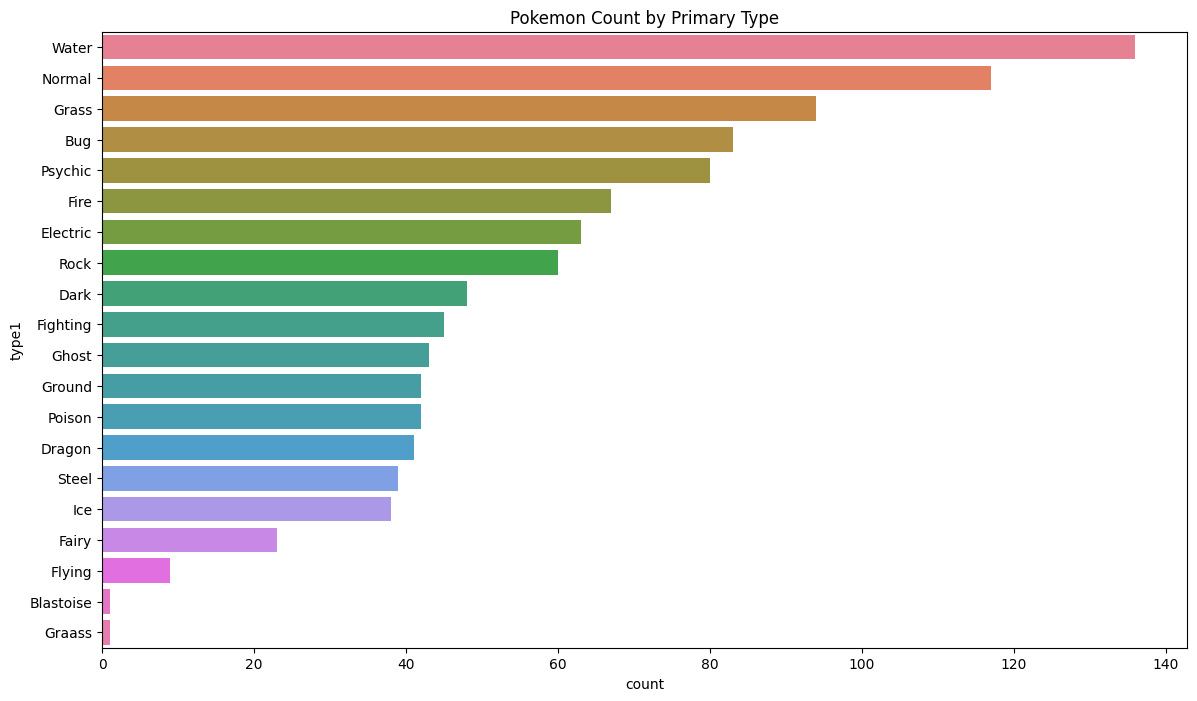

In [19]:
plt.figure(figsize=(14,8))

sns.countplot(
    y='type1',
    data=df,
    order=df['type1'].value_counts().index,
    palette='husl'
)

plt.title('Pokemon Count by Primary Type')
plt.show()

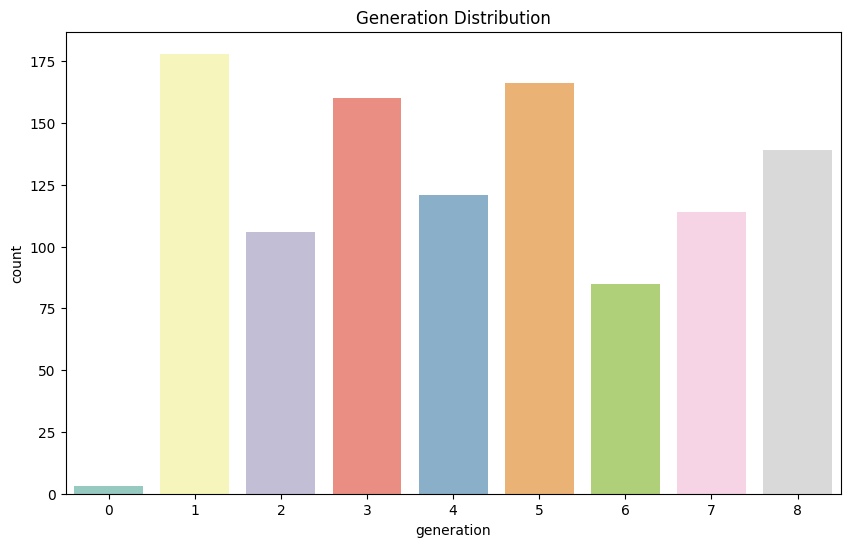

In [20]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='generation',
    data=df,
    palette='Set3'
)

plt.title('Generation Distribution')
plt.show()

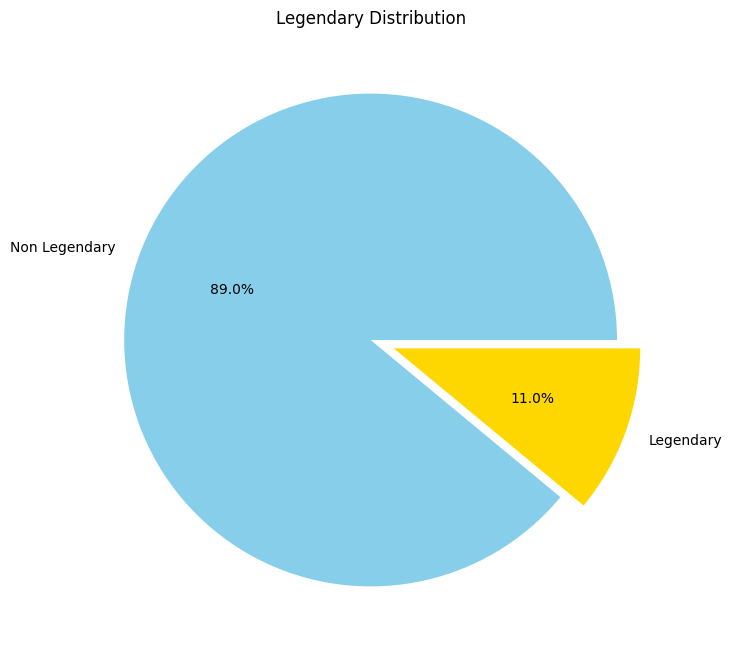

In [21]:
legend_counts = df['legendary'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    legend_counts,
    labels=['Non Legendary','Legendary'],
    autopct='%1.1f%%',
    colors=['skyblue','gold'],
    explode=[0,0.1]
)

plt.title('Legendary Distribution')
plt.show()

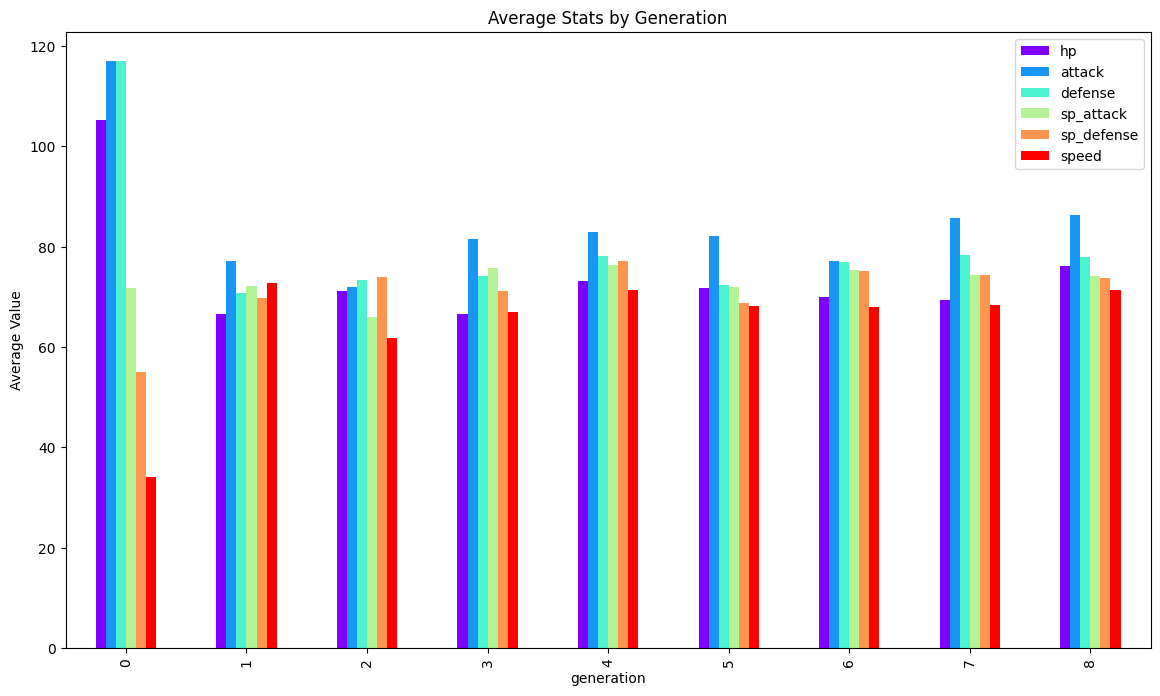

In [22]:
stats = ['hp','attack','defense','sp_attack','sp_defense','speed']

gen_stats = df.groupby('generation')[stats].mean()

gen_stats.plot(
    kind='bar',
    figsize=(14,8),
    colormap='rainbow'
)

plt.title('Average Stats by Generation')
plt.ylabel('Average Value')
plt.show()

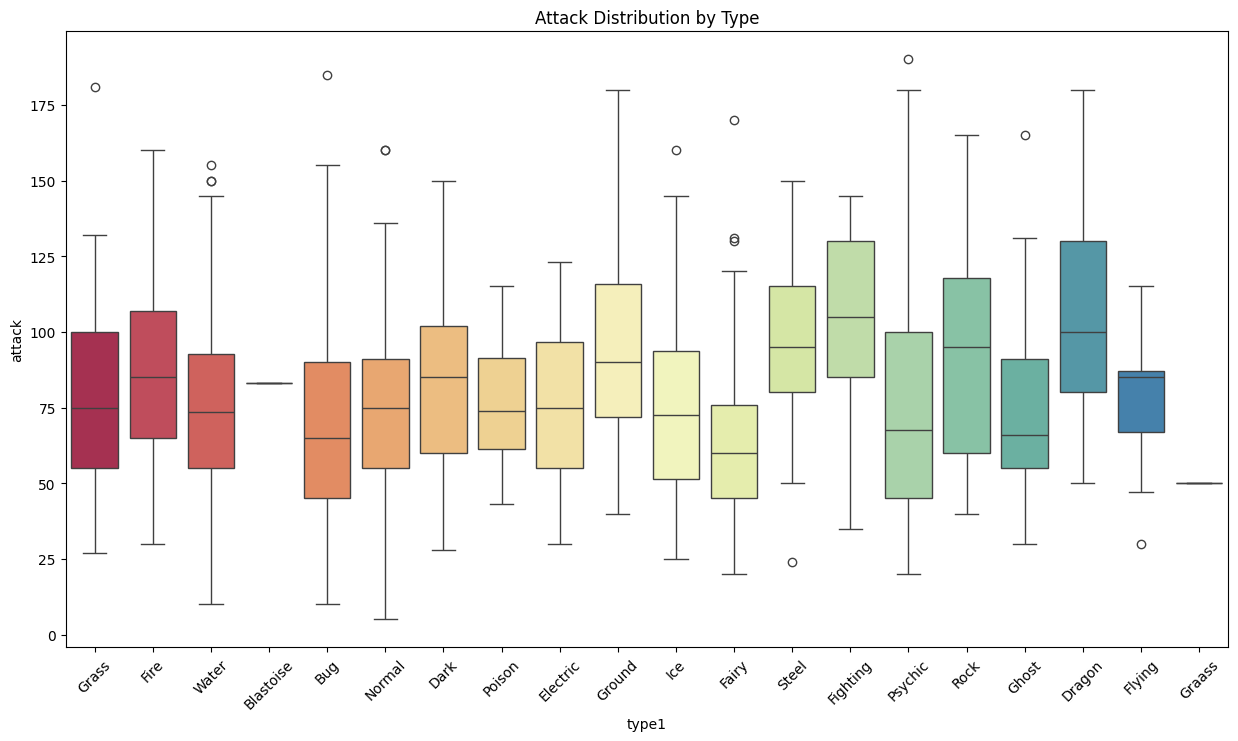

In [23]:
plt.figure(figsize=(15,8))

sns.boxplot(
    x='type1',
    y='attack',
    data=df,
    palette='Spectral'
)

plt.xticks(rotation=45)
plt.title('Attack Distribution by Type')
plt.show()

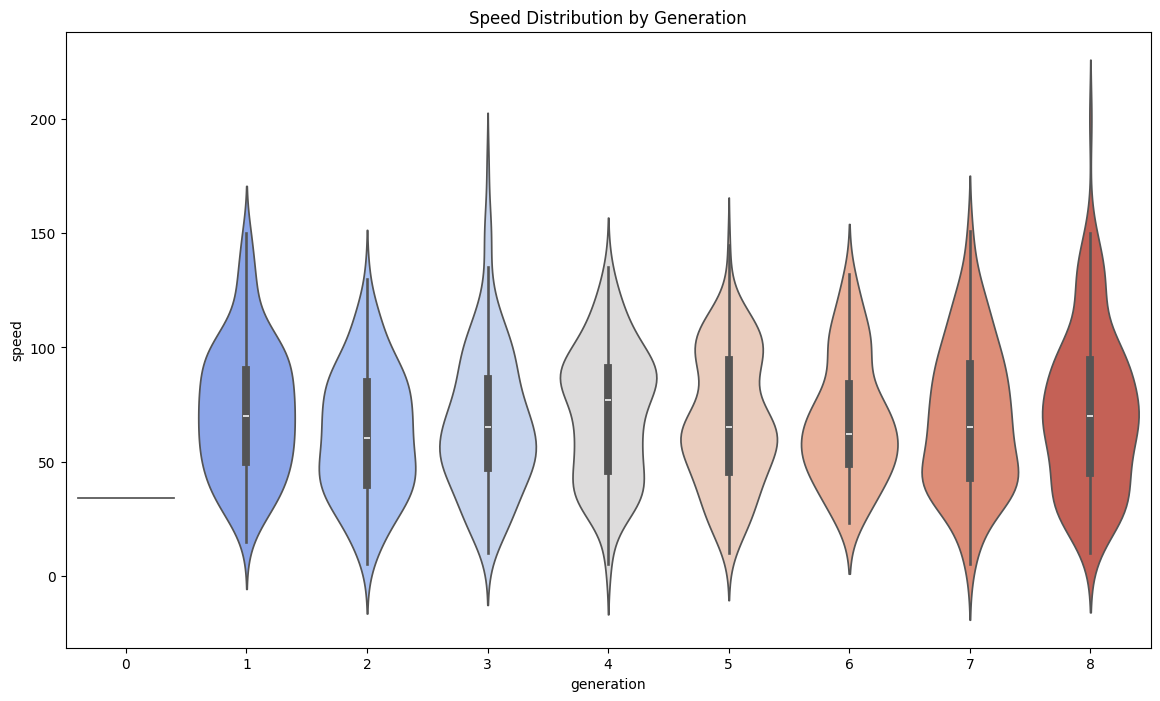

In [24]:
plt.figure(figsize=(14,8))

sns.violinplot(
    x='generation',
    y='speed',
    data=df,
    palette='coolwarm'
)

plt.title('Speed Distribution by Generation')
plt.show()

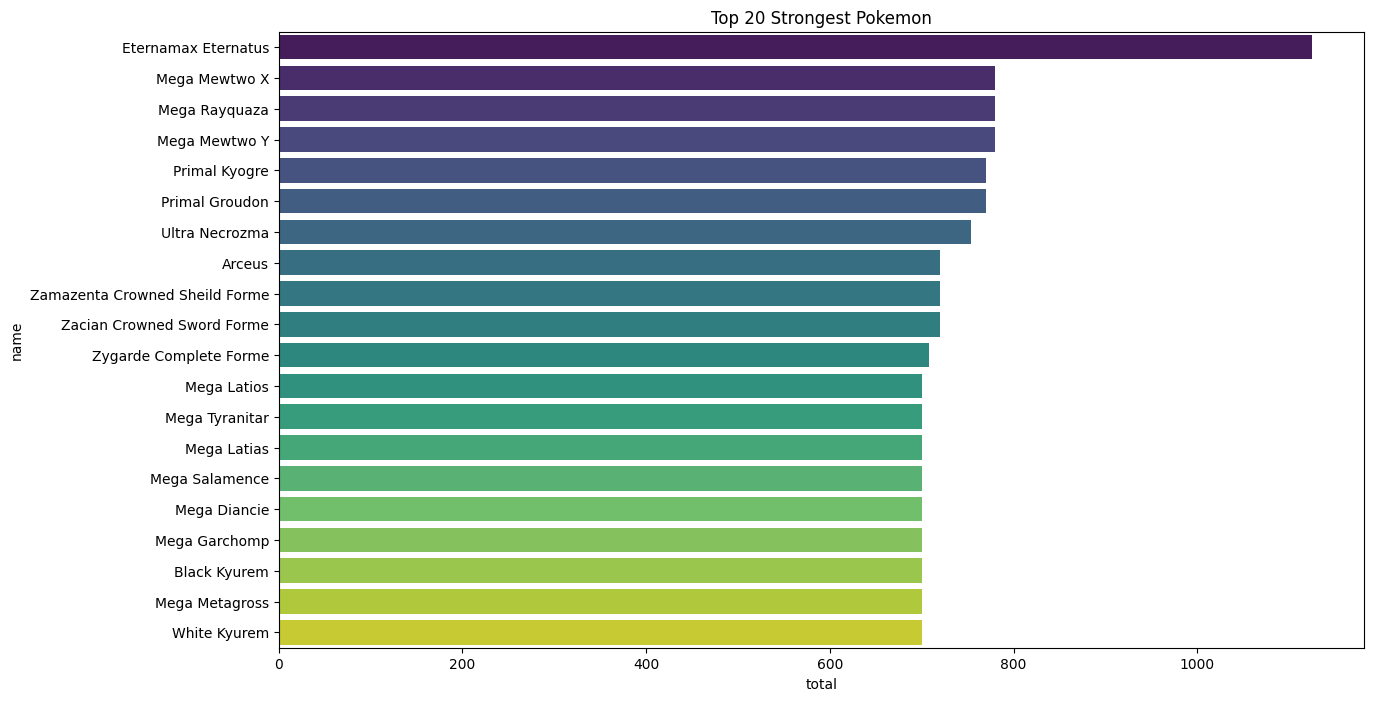

In [25]:
top20 = df.sort_values('total', ascending=False).head(20)

plt.figure(figsize=(14,8))

sns.barplot(
    x='total',
    y='name',
    data=top20,
    palette='viridis'
)

plt.title('Top 20 Strongest Pokemon')
plt.show()

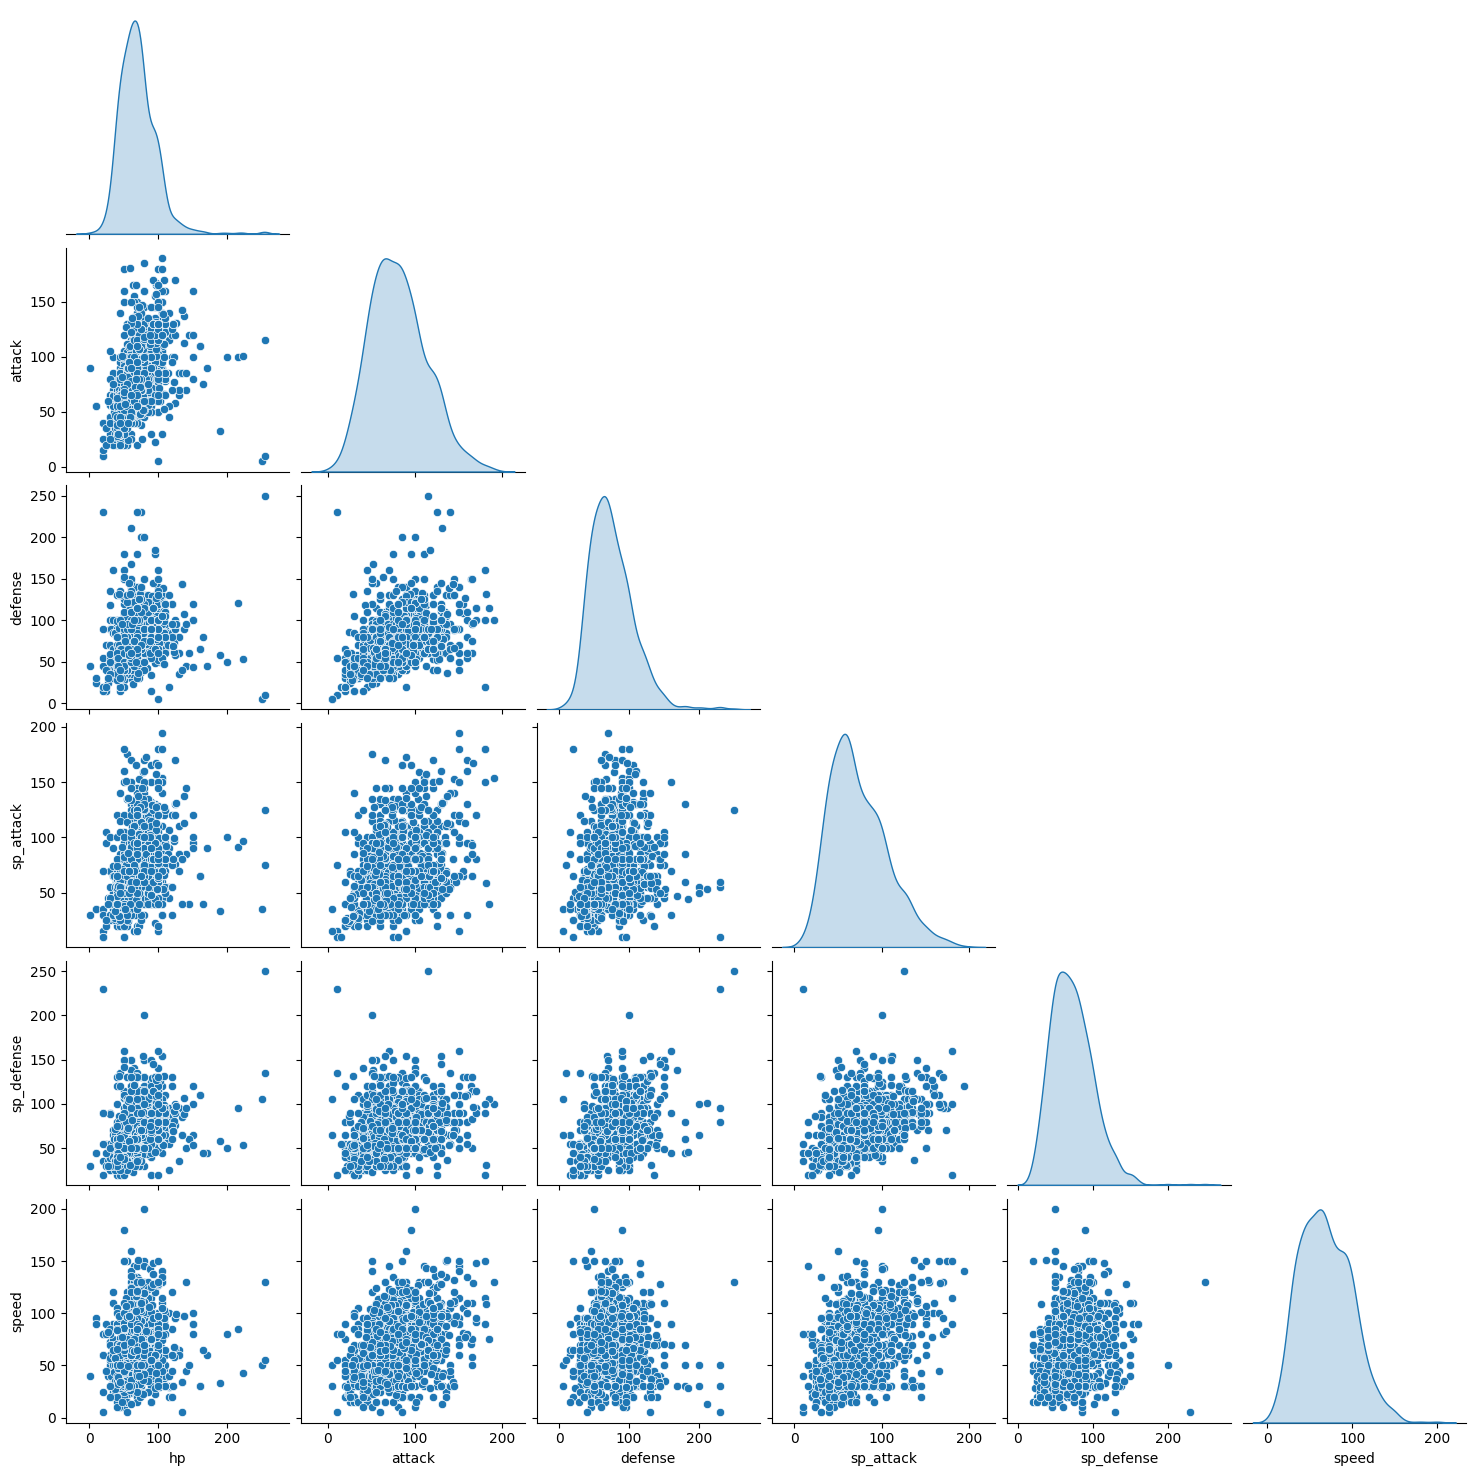

In [26]:
cols = ['hp','attack','defense',
        'sp_attack','sp_defense','speed']

sns.pairplot(
    df[cols],
    corner=True,
    diag_kind='kde'
)

plt.show()

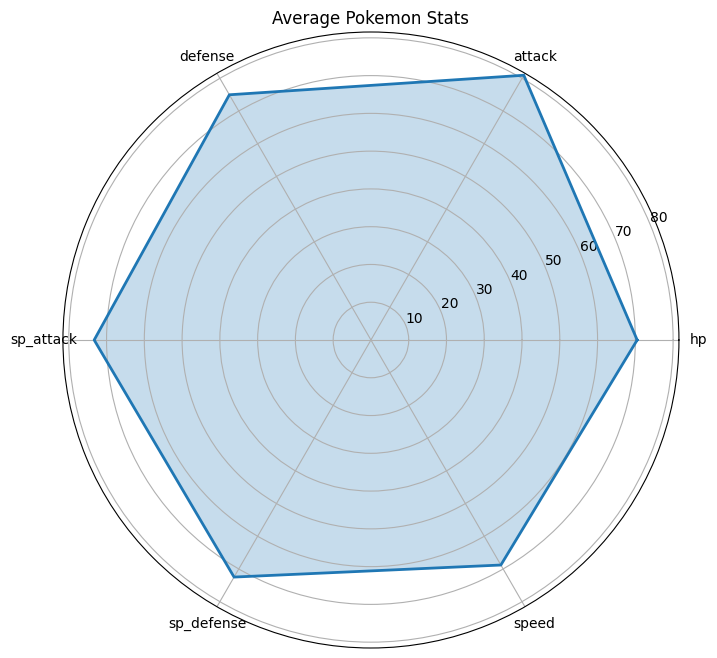

In [27]:
import numpy as np

stats = ['hp','attack','defense',
         'sp_attack','sp_defense','speed']

avg_stats = df[stats].mean()

angles = np.linspace(
    0,
    2*np.pi,
    len(stats),
    endpoint=False
).tolist()

values = avg_stats.tolist()
values += values[:1]

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(8,8),
    subplot_kw=dict(polar=True)
)

ax.plot(angles, values, linewidth=2)
ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(stats)

plt.title('Average Pokemon Stats')
plt.show()

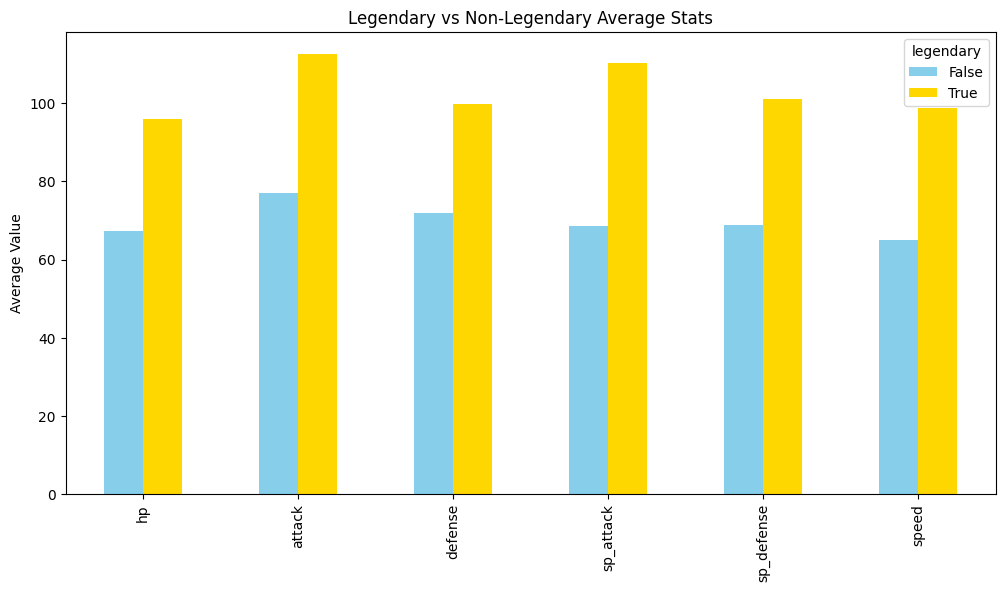

In [28]:
stats = ['hp','attack','defense',
         'sp_attack','sp_defense','speed']

legend_stats = df.groupby('legendary')[stats].mean().T

legend_stats.plot(
    kind='bar',
    figsize=(12,6),
    color=['skyblue','gold']
)

plt.title('Legendary vs Non-Legendary Average Stats')
plt.ylabel('Average Value')
plt.show()

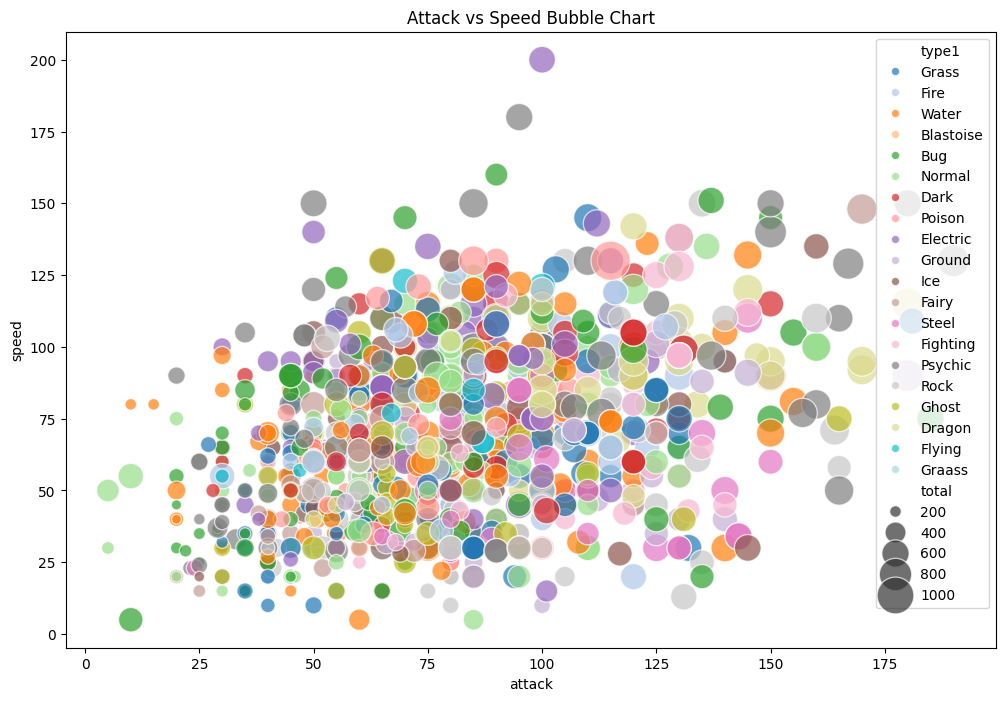

In [29]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x='attack',
    y='speed',
    size='total',
    hue='type1',
    sizes=(50,800),
    alpha=0.7,
    palette='tab20'
)

plt.title('Attack vs Speed Bubble Chart')
plt.show()

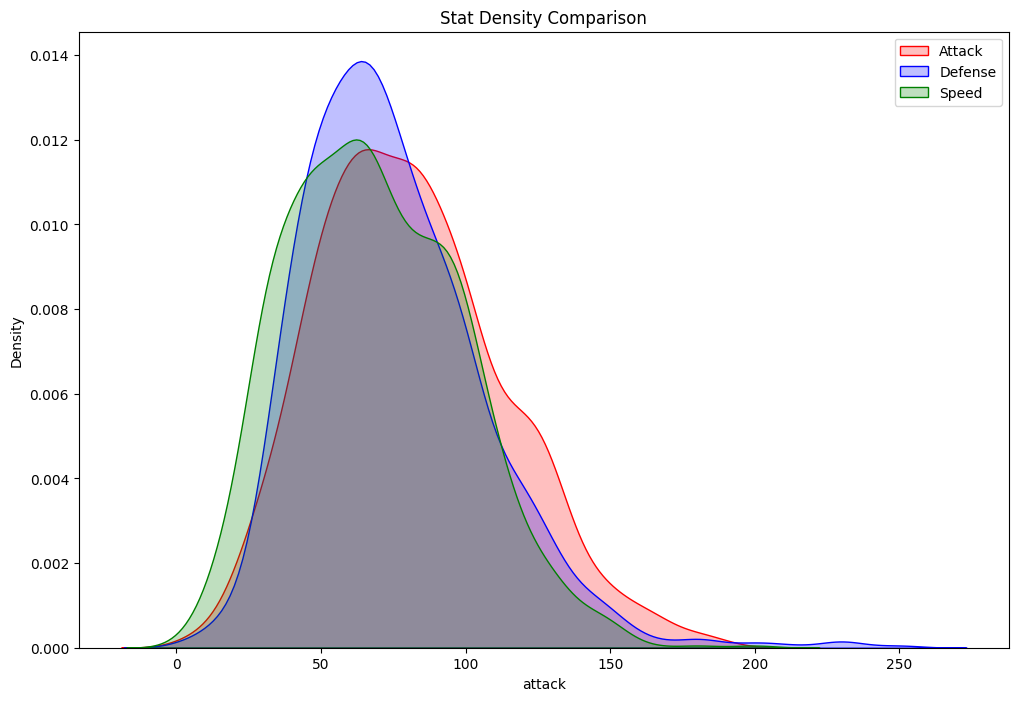

In [30]:
plt.figure(figsize=(12,8))

sns.kdeplot(df['attack'],
            fill=True,
            color='red',
            label='Attack')

sns.kdeplot(df['defense'],
            fill=True,
            color='blue',
            label='Defense')

sns.kdeplot(df['speed'],
            fill=True,
            color='green',
            label='Speed')

plt.legend()
plt.title('Stat Density Comparison')
plt.show()

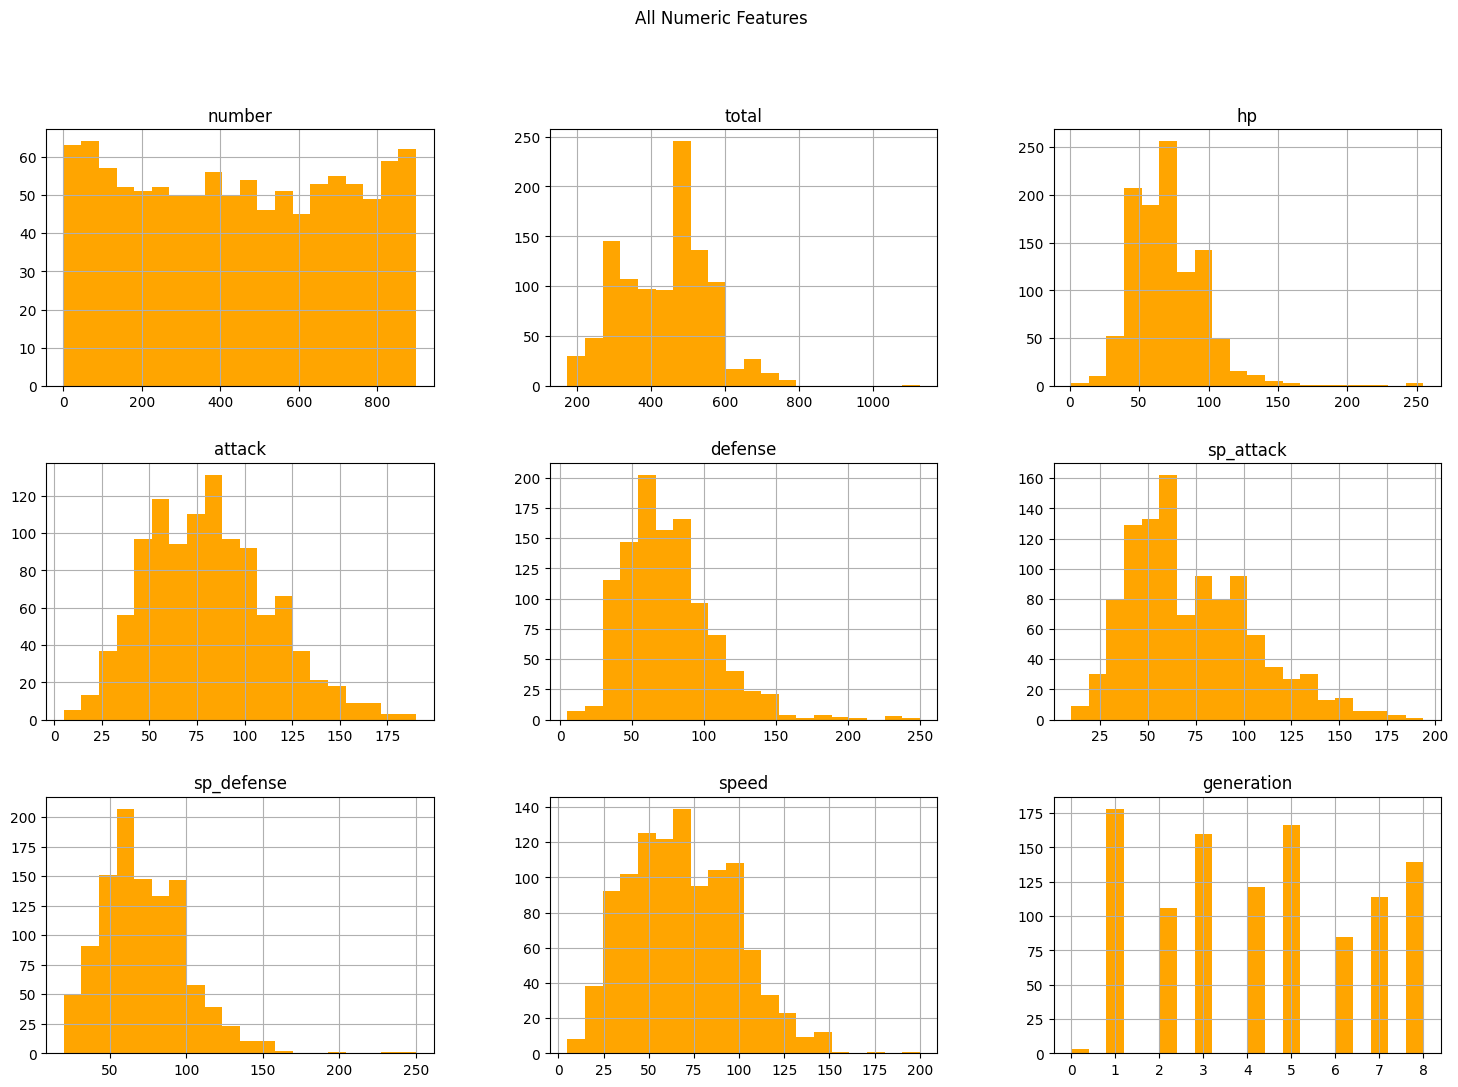

In [31]:
df.select_dtypes(include=np.number).hist(
    figsize=(18,12),
    bins=20,
    color='orange'
)

plt.suptitle('All Numeric Features')
plt.show()

## Feature engineering

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.neighbors import KNeighborsClassifier

In [33]:
target = 'legendary'

X = df.drop(columns=[target])
y = df[target]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (857, 12)
Test Shape: (215, 12)


In [35]:
categorical_cols = [
    'name',
    'type1',
    'type2'
]

numerical_cols = [
    'number',
    'total',
    'hp',
    'attack',
    'defense',
    'sp_attack',
    'sp_defense',
    'speed',
    'generation'
]

In [36]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [37]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=5000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(
        random_state=42
    ),

    "Extra Trees":
    ExtraTreesClassifier(
        n_estimators=300,
        random_state=42
    ),

    "KNN":
    KNeighborsClassifier(
        n_neighbors=5
    )
}

In [38]:
results = []

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ]
    )

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    y_prob = pipe.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    print("\n")
    print("="*60)
    print(name)
    print("="*60)

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    print(
        "ROC AUC:",
        round(roc_auc,4)
    )



Logistic Regression
              precision    recall  f1-score   support

       False       0.95      1.00      0.97       191
        True       1.00      0.58      0.74        24

    accuracy                           0.95       215
   macro avg       0.98      0.79      0.86       215
weighted avg       0.96      0.95      0.95       215

ROC AUC: 0.9727


Decision Tree
              precision    recall  f1-score   support

       False       0.95      0.98      0.97       191
        True       0.83      0.62      0.71        24

    accuracy                           0.94       215
   macro avg       0.89      0.80      0.84       215
weighted avg       0.94      0.94      0.94       215

ROC AUC: 0.8046


Random Forest
              precision    recall  f1-score   support

       False       0.95      1.00      0.97       191
        True       1.00      0.54      0.70        24

    accuracy                           0.95       215
   macro avg       0.97      0.77      0.8

In [39]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df = results_df.sort_values(
    by='ROC AUC',
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
3    Gradient Boosting  0.962791   0.900000  0.750000  0.818182  0.976003
0  Logistic Regression  0.953488   1.000000  0.583333  0.736842  0.972731
4          Extra Trees  0.934884   1.000000  0.416667  0.588235  0.970659
2        Random Forest  0.948837   1.000000  0.541667  0.702703  0.969895
5                  KNN  0.958140   0.857143  0.750000  0.800000  0.968586
1        Decision Tree  0.944186   0.833333  0.625000  0.714286  0.804647


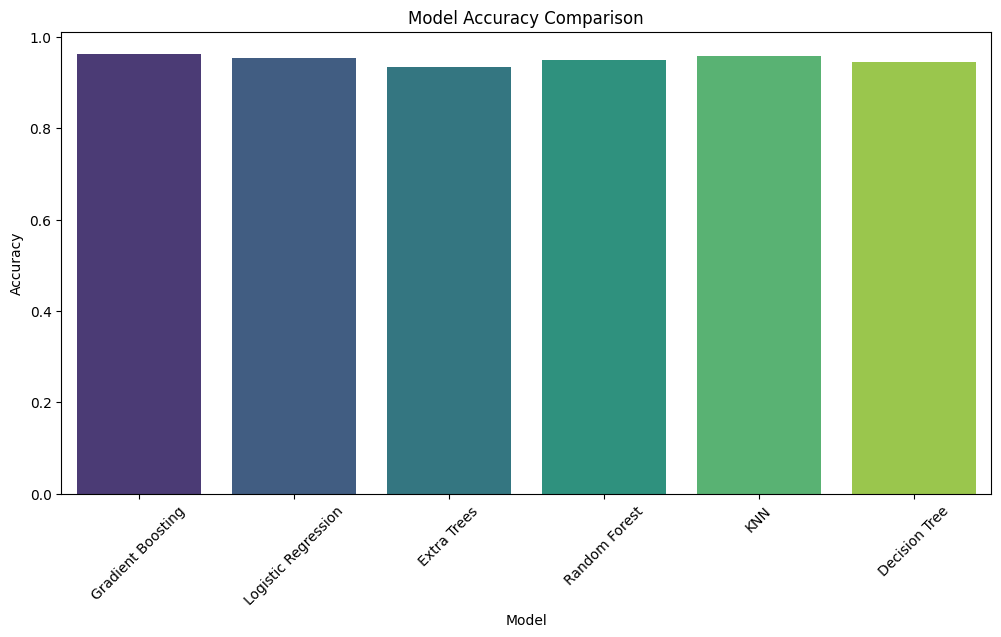

In [40]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='Accuracy',
    palette='viridis'
)

plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.show()

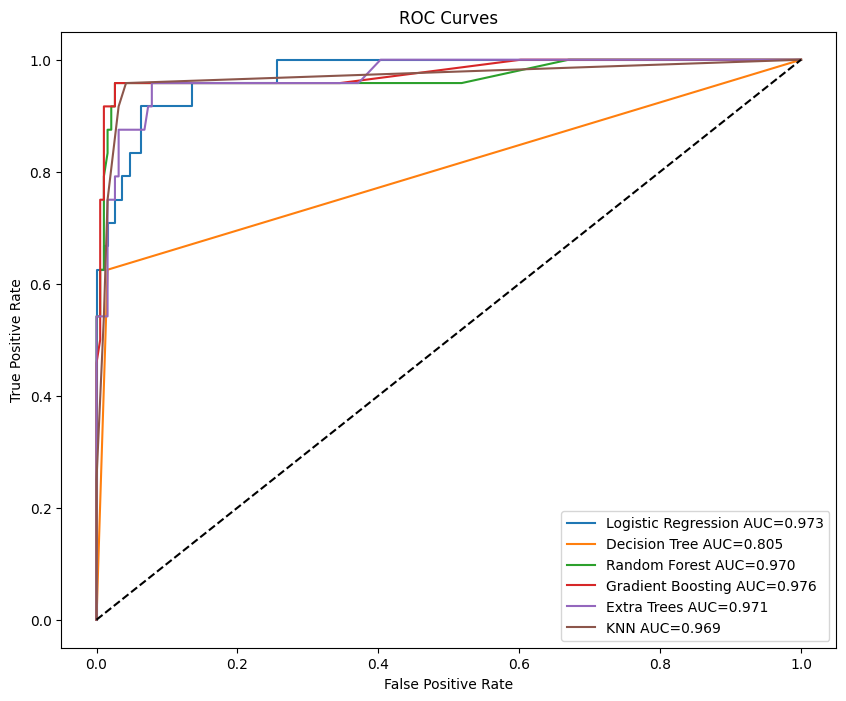

In [41]:
plt.figure(figsize=(10,8))

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ]
    )

    pipe.fit(X_train, y_train)

    y_prob = pipe.predict_proba(X_test)[:,1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC={auc_score:.3f}"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

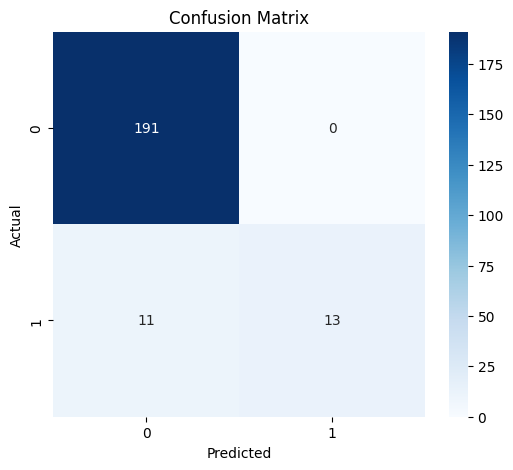

In [42]:
best_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

best_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', best_model)
    ]
)

best_pipe.fit(
    X_train,
    y_train
)

y_pred = best_pipe.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

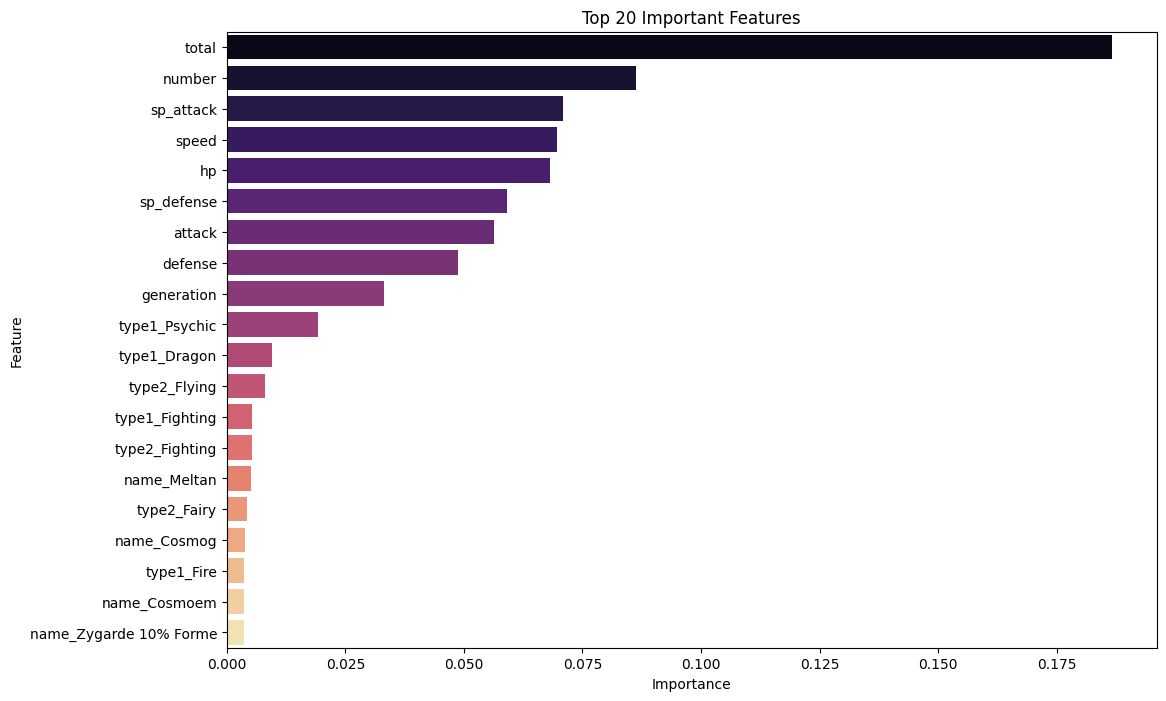

In [43]:
rf_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier',
         RandomForestClassifier(
             n_estimators=300,
             random_state=42
         ))
    ]
)

rf_pipe.fit(
    X_train,
    y_train
)

feature_names = (
    numerical_cols +
    list(
        rf_pipe.named_steps[
            'preprocessor'
        ]
        .named_transformers_[
            'cat'
        ]
        .named_steps[
            'onehot'
        ]
        .get_feature_names_out(
            categorical_cols
        )
    )
)

importances = rf_pipe.named_steps[
    'classifier'
].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette='magma'
)

plt.title('Top 20 Important Features')
plt.show()

## Thank you..pls upvote!!!!!!!!!!!!!